# Data Anlaysis of 2024 ANES DATA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [2]:
data_path = os.getenv("ANES_DATA_PATH")
anes_24 = pd.read_csv(data_path, low_memory=False)

In [3]:
anes_24.describe()

,V240001,V200001,V160001_orig,V240002a,V240002b,V240002c,V240003,V240107a,V240107c,V240107d,...,V245008,V245009,V245011,V245012,V245013,V245014,V245015,V245016,V245017,V245018
count,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,...,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000,5521.000000
mean,214468.828473,85779.698424,149691.869408,1.896939,1.426915,1.899112,1.795508,1.000000,24.911610,69.830647,...,-0.685745,-0.603333,250.426191,-0.858721,-1.164825,-0.977359,-0.568556,-0.796595,-0.704583,-0.698605
std,77453.441194,106769.551324,187910.024862,0.513647,2.660526,0.301207,0.735011,1.054148,65.369314,36.675315,...,0.683099,0.954328,657.642506,2.075207,1.648452,1.863171,2.637257,0.483529,0.681161,0.790166
min,140001.000000,-1.000000,-1.000000,1.000000,-7.000000,1.000000,1.000000,0.045193,1.000000,1.000000,...,-1.000000,-1.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-1.000000,-1.000000,-1.000000
25%,141692.000000,-1.000000,-1.000000,2.000000,2.000000,2.000000,1.000000,0.358461,1.000000,33.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,210620.000000,-1.000000,-1.000000,2.000000,2.000000,2.000000,2.000000,0.612811,2.000000,72.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
75%,234292.000000,213172.000000,401400.000000,2.000000,2.000000,2.000000,2.000000,1.177523,20.000000,101.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
max,399909.000000,236427.000000,407791.000000,4.000000,5.000000,2.000000,3.000000,5.000000,425.000000,134.000000,...,1.000000,3.000000,2000.000000,4.000000,2.000000,2.000000,9.000000,1.000000,1.000000,3.000000


In [4]:
anes_issue_mapping = {
    "Defense Spending": "V241242",
    "Israel/Palestine": "V241409x",
    "Terrorism": "V242343",
    "Free Trade" : "V242346x",
    "Protection of American Jobs": "V242226x",
    "China": "V242365",
    "Environment": "V241260",
    "School funding": "V241266x",
    "Health care": "V242353x", # can be combination of V242351 and V242352
    "Welfare": "V241275x", # can be combination of V241273  and V241274
    "Aid to the poor": "V241281x", # can be combination of V241279 and V241280
    "Income Inequality": "V242252",
    "Employment/Income": "V241252",
    "Social Security": "V241263x",
    "Cost of living": "V242173",
    "Crime": "V241272x", # can be combination of V241270 and V241271
    "Race relations": "V242349x", # can be combination of V242347 and V242348
    "Opioid Crisis": "V242335x", # can be combination of V242334 and V242335
    "Policing": "V241397",
    "Gun Control": "V242328x", # can be combination of V242326 and V242327
    "Corruption": "V242456",
    "Budget deficit": "V242315",
    "Tax on the rich": "V242316b",
    "Immigration": "V242227",
    "Campaign spending": "V242214",
    "Separation of powers in government": "V241325",
    "Economy": "V241236", # note this asks who does better job (Democrat or Republican) on the economy, biased by partisan politics
    "Science": "V242420",
    "Invested in stock market": "V241554",
    "Building/repairing highways": "V241278x",
    "Abortion": "V241248",
    "Traditional family values": "V242259",
    "LGB rights": "V241381x", # can be combination of V241379 and V241380
    "Transgender rights": "V241375x",
    "Traditional media": "V242422",
    "Social media": "V242423",
    "Sexism": "V242281",
    "Sexual Harrassment": "V242361x",
    "Voter ID": "V241319x",
    "Religion": "V241420",
}

In [5]:
anes_24_issues = anes_24[list(anes_issue_mapping.values())]
anes_24_issues = anes_24_issues.rename(columns={v: k for k, v in anes_issue_mapping.items()})

In [6]:
anes_24_issues.head()

,Defense Spending,Israel/Palestine,Terrorism,Free Trade,Protection of American Jobs,China,Environment,School funding,Health care,Welfare,...,Abortion,Traditional family values,LGB rights,Transgender rights,Traditional media,Social media,Sexism,Sexual Harrassment,Voter ID,Religion
0,5,1,3,2,2,5,6,3,6,5,...,4,2,6,1,4,3,5,5,1,2
1,4,8,3,4,3,4,6,1,4,3,...,1,4,1,3,4,4,4,3,3,5
2,1,4,4,4,4,3,7,1,1,1,...,1,5,1,7,2,3,5,5,6,5
3,99,8,1,2,4,4,1,1,4,3,...,5,2,2,7,2,3,2,3,2,1
4,3,4,3,7,1,4,4,5,7,3,...,6,2,5,1,4,2,2,3,1,3


In [7]:
for i in anes_issue_mapping.values():
    print(i)

V241242
V241409x
V242343
V242346x
V242226x
V242365
V241260
V241266x
V242353x
V241275x
V241281x
V242252
V241252
V241263x
V242173
V241272x
V242349x
V242335x
V241397
V242328x
V242456
V242315
V242316b
V242227
V242214
V241325
V241236
V242420
V241554
V241278x
V241248
V242259
V241381x
V241375x
V242422
V242423
V242281
V242361x
V241319x
V241420


In [8]:
extraneous_responses = {
    -9: "Refused",
    -8: "Don't know",
    -7: "Insuﬃcient partial, interview deleted",
    -6: "No post interview",
    -5: "Suﬃcient partial, breakoﬀ",
    -4: "Error",
    -3: "RESTRICTED",
    -2: "DK/RF in V241407 or V241408",
    -1: "Inapplicable",
    95: "Haven't heard of left-right",
    96: "Do not know enough about party",
    97: "Do not know enough about candidate",
    98: "Refused (VOL)",
    99: "Haven't though much about this",
    998: "Don’t know (where to rate)",
    999: "Dont recognize"
}

In [9]:
# Replace extraneous responses with NaN
anes_24_issues.replace(extraneous_responses.keys(), np.nan, inplace=True)

# Make number 8 (side with neither) into 4 (side with both equally) for isreal/palestine
anes_24_issues['Israel/Palestine'] = anes_24_issues['Israel/Palestine'].replace(8, 4)

# For campaign spending swap 2 and 3 values since 3 is 'neither favor or oppose' and 2 is 'oppose' and 1 is 'favor'
anes_24_issues['Campaign spending'] = anes_24_issues['Campaign spending'].replace({2: 3, 3: 2})

anes_24_issues.head()

,Defense Spending,Israel/Palestine,Terrorism,Free Trade,Protection of American Jobs,China,Environment,School funding,Health care,Welfare,...,Abortion,Traditional family values,LGB rights,Transgender rights,Traditional media,Social media,Sexism,Sexual Harrassment,Voter ID,Religion
0,5.0,1.0,3.0,2.0,2.0,5.0,6.0,3.0,6.0,5.0,...,4.0,2.0,6.0,1.0,4.0,3.0,5.0,5.0,1.0,2.0
1,4.0,4.0,3.0,4.0,3.0,4.0,6.0,1.0,4.0,3.0,...,1.0,4.0,1.0,3.0,4.0,4.0,4.0,3.0,3.0,5.0
2,1.0,4.0,4.0,4.0,4.0,3.0,7.0,1.0,1.0,1.0,...,1.0,5.0,1.0,7.0,2.0,3.0,5.0,5.0,6.0,5.0
3,NaN,4.0,1.0,2.0,4.0,4.0,1.0,1.0,4.0,3.0,...,5.0,2.0,2.0,7.0,2.0,3.0,2.0,3.0,2.0,1.0
4,3.0,4.0,3.0,7.0,1.0,4.0,4.0,5.0,7.0,3.0,...,6.0,2.0,5.0,1.0,4.0,2.0,2.0,3.0,1.0,3.0


In [10]:
anes_24_issues.describe()

,Defense Spending,Israel/Palestine,Terrorism,Free Trade,Protection of American Jobs,China,Environment,School funding,Health care,Welfare,...,Abortion,Traditional family values,LGB rights,Transgender rights,Traditional media,Social media,Sexism,Sexual Harrassment,Voter ID,Religion
count,4587.000000,5201.000000,4716.000000,4681.000000,4652.000000,4894.000000,5128.000000,5244.000000,4692.000000,5219.000000,...,4944.000000,4721.000000,5168.000000,5231.000000,4907.000000,4688.000000,4693.000000,4687.000000,5263.000000,5494.000000
mean,4.518422,3.475678,3.117684,3.206153,2.528375,3.767062,5.716459,1.931350,3.016837,2.946925,...,3.304814,2.451599,2.368615,3.196903,2.655594,3.216724,3.862987,3.226584,2.317500,2.804150
std,1.708167,1.591152,1.182381,1.473416,1.144594,1.133123,1.610608,1.152437,1.744845,1.253152,...,2.011279,1.315101,1.784760,2.196694,0.867255,0.741038,1.046541,1.217262,1.798922,1.484139
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.000000,2.000000,2.000000,2.000000,1.000000,3.000000,5.000000,1.000000,2.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,3.000000,3.000000,1.000000,1.000000
50%,5.000000,4.000000,3.000000,4.000000,3.000000,4.000000,6.000000,1.000000,3.000000,3.000000,...,3.000000,2.000000,2.000000,3.000000,3.000000,3.000000,4.000000,3.000000,1.000000,3.000000
75%,6.000000,4.000000,4.000000,4.000000,4.000000,5.000000,7.000000,3.000000,4.000000,4.000000,...,5.000000,3.000000,3.000000,4.000000,3.000000,4.000000,5.000000,4.000000,4.000000,4.000000
max,7.000000,7.000000,5.000000,7.000000,4.000000,5.000000,7.000000,5.000000,7.000000,5.000000,...,7.000000,5.000000,6.000000,7.000000,4.000000,4.000000,5.000000,5.000000,7.000000,5.000000


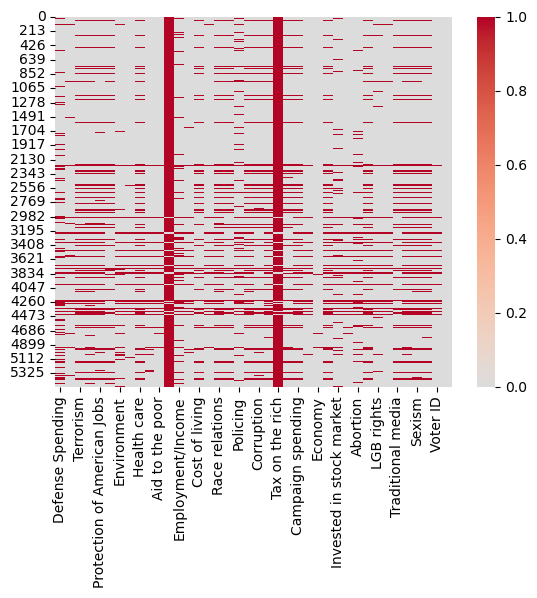

In [11]:
# plot anes_24_issues.isna() as a heatmap to visualize missing values

sns.heatmap(anes_24_issues.isna(), cmap="coolwarm", center=0)
plt.show()

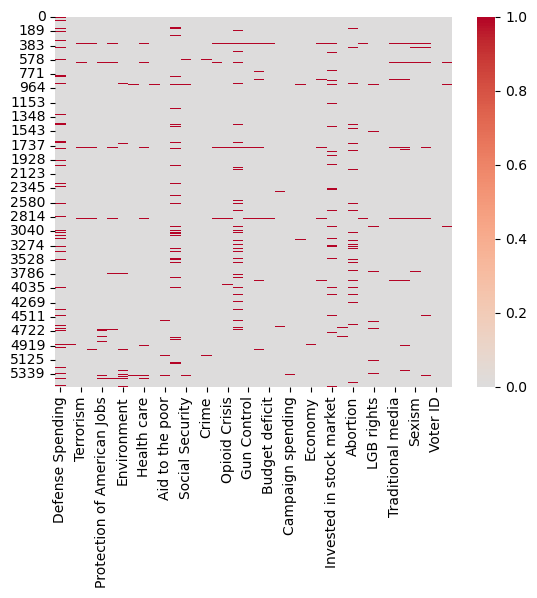

Original shape: (5521, 40)
Cleaned shape: (4735, 38)


In [12]:
# remove rows with over 50% missing values
# remove columns with over 67% missing values
anes_24_issues_clean = anes_24_issues.dropna(thresh=anes_24_issues.shape[1] * 0.5, axis=0)
anes_24_issues_clean = anes_24_issues_clean.dropna(thresh=anes_24_issues.shape[0] * 0.33, axis=1)

sns.heatmap(anes_24_issues_clean.isna(), cmap="coolwarm", center=0)
plt.show()

print(f"Original shape: {anes_24_issues.shape}")
print(f"Cleaned shape: {anes_24_issues_clean.shape}")

## Matrix Completion

In [13]:
# Fill NaN values with iterative singular value thresholding (soft-impute style)
def singular_value_thresholding(X, tau=0.5, stopping_criteria=1e-5, max_iter=500):
    X_values = X.to_numpy(dtype=float) if hasattr(X, "to_numpy") else np.asarray(X, dtype=float)
    observed_mask = ~np.isnan(X_values)
    X_filled = np.where(observed_mask, X_values, 0.0)

    for _ in range(max_iter):
        X_prev = X_filled.copy()
        U, s, Vt = np.linalg.svd(X_filled, full_matrices=False)
        s_hat = np.maximum(s - tau, 0.0)
        X_recon = U @ np.diag(s_hat) @ Vt

        # Keep observed entries fixed; only update missing entries.
        X_filled = np.where(observed_mask, X_values, X_recon)

        delta = np.linalg.norm(X_filled - X_prev, ord="fro")
        if delta < stopping_criteria:
            break

    if hasattr(X, "index") and hasattr(X, "columns"):
        return pd.DataFrame(X_filled, index=X.index, columns=X.columns)
    return X_filled

In [14]:
anes_24_issues_completed = singular_value_thresholding(anes_24_issues_clean, tau=0.5, stopping_criteria=1e-5)

In [15]:
anes_24_issues_completed.describe()

,Defense Spending,Israel/Palestine,Terrorism,Free Trade,Protection of American Jobs,China,Environment,School funding,Health care,Welfare,...,Abortion,Traditional family values,LGB rights,Transgender rights,Traditional media,Social media,Sexism,Sexual Harrassment,Voter ID,Religion
count,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000,...,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000,4735.000000
mean,4.349573,3.470584,3.115097,3.198085,2.524478,3.769912,5.716747,1.934042,3.012496,2.938068,...,3.241739,2.451052,2.340211,3.204332,2.654707,3.213047,3.858124,3.221059,2.319483,2.817677
std,1.662533,1.579707,1.180867,1.467194,1.137194,1.132086,1.595277,1.154864,1.738648,1.247585,...,1.958743,1.313341,1.760843,2.201397,0.864606,0.738624,1.043714,1.212677,1.803773,1.490784
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.874118,1.000000,0.899558,...,0.562669,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2.000000,2.000000,2.000000,1.000000,3.000000,5.000000,1.000000,2.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,3.000000,3.000000,1.000000,1.000000
50%,4.000000,4.000000,3.000000,4.000000,3.000000,4.000000,6.000000,1.000000,2.910884,3.000000,...,3.000000,2.000000,2.000000,3.000000,3.000000,3.000000,4.000000,3.000000,1.000000,3.000000
75%,6.000000,4.000000,4.000000,4.000000,4.000000,5.000000,7.000000,3.000000,4.000000,4.000000,...,5.000000,3.000000,3.000000,4.000000,3.000000,4.000000,5.000000,4.000000,4.000000,4.000000
max,7.000000,7.000000,5.000000,7.000000,4.000000,5.000000,7.000000,5.000000,7.000000,5.000000,...,7.000000,5.000000,6.000000,7.000000,4.000000,4.000000,5.000000,5.000000,7.000000,5.000000


## Principal Component Analysis

In [16]:
# run PCA on the completed dataset

pca = PCA(n_components=5)
anes_24_issues_pca = pca.fit_transform(anes_24_issues_completed)

In [17]:
print(f"Principal component 1: {anes_24_issues_pca[:, 0]}, Explained variance percent: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Principal component 2: {anes_24_issues_pca[:, 1]}, Explained variance percent: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Principal component 3: {anes_24_issues_pca[:, 2]}, Explained variance percent: {pca.explained_variance_ratio_[2]*100:.2f}%")
print(f"Principal component 4: {anes_24_issues_pca[:, 3]}, Explained variance percent: {pca.explained_variance_ratio_[3]*100:.2f}%")
print(f"Principal component 5: {anes_24_issues_pca[:, 4]}, Explained variance percent: {pca.explained_variance_ratio_[4]*100:.2f}%")

Principal component 1: [ 7.11294303 -1.55694127 -9.46680007 ... -0.88736983 -6.7176391
  4.11452124], Explained variance percent: 29.13%
Principal component 2: [ 1.40344754  2.34270464  0.71221595 ...  1.75090111 -0.28638416
 -0.25026589], Explained variance percent: 6.34%
Principal component 3: [ 0.67415779 -1.63081618 -1.12244567 ...  0.76727675  0.8357231
  0.48304793], Explained variance percent: 5.95%
Principal component 4: [ 0.47687614 -1.2913369   1.35375977 ...  0.18049011  1.11403478
 -0.88532305], Explained variance percent: 4.92%
Principal component 5: [ 0.88470493 -2.2207226   1.14430718 ... -0.79214605 -1.1221973
 -0.6931167 ], Explained variance percent: 4.33%


In [18]:
for component_index in range(3):
    loadings = pd.Series(pca.components_[component_index], index=anes_24_issues_completed.columns)
    ranked_loadings = loadings.reindex(loadings.abs().sort_values(ascending=False).index).head(5)
    print(f"Principal component {component_index + 1} loadings (largest magnitude first):")
    print(ranked_loadings.to_string())
    print()

Principal component 1 loadings (largest magnitude first):
Policing              0.351028
Abortion              0.323316
Transgender rights   -0.313649
Employment/Income     0.290447
Economy               0.254339

Principal component 2 loadings (largest magnitude first):
Environment          0.394705
Employment/Income    0.390005
Religion             0.308046
LGB rights          -0.280834
Health care          0.248658

Principal component 3 loadings (largest magnitude first):
Defense Spending    0.374530
Opioid Crisis      -0.344270
Gun Control        -0.339202
Free Trade         -0.300429
Environment         0.281843

